In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/all_bank_reviews.csv")
df.head()

,review_id,user_name,review,rating,thumbs_up,review_date,bank,clean_review
0,eb3cc438-1c10-4e72-8851-3efff6a04135,Hamza Jemal,this app very full,5,0,2026-05-16 09:17:00,CBE,thisappveryfull
1,f8209985-ea16-4f28-bb48-d6a7276f0f08,Ras Abale,good apps,4,0,2026-05-16 07:18:33,CBE,goodapps
2,f0f249ac-ba95-4ad8-ad1d-c435693b7bf9,Abrha Hadgu,this update got crazy i don't know what's goin...,1,0,2026-05-15 23:20:32,CBE,thisupdategotcrazyidontknowwhatsgoingonthisapp...
3,31cf1f70-1cd8-427c-9cd5-1ccb4113facf,Ademasu Shadaga,thanks for you 😘,5,0,2026-05-15 20:11:22,CBE,thanksforyou
4,7019e213-93dc-4f00-bff3-80cfb80e5d3a,suutu sura89,it's okay,4,0,2026-05-15 19:53:26,CBE,itsokay


In [2]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

In [3]:
df["sentiment"] = df["review"].apply(get_sentiment)
df.head()

,review_id,user_name,review,rating,thumbs_up,review_date,bank,clean_review,sentiment
0,eb3cc438-1c10-4e72-8851-3efff6a04135,Hamza Jemal,this app very full,5,0,2026-05-16 09:17:00,CBE,thisappveryfull,neutral
1,f8209985-ea16-4f28-bb48-d6a7276f0f08,Ras Abale,good apps,4,0,2026-05-16 07:18:33,CBE,goodapps,positive
2,f0f249ac-ba95-4ad8-ad1d-c435693b7bf9,Abrha Hadgu,this update got crazy i don't know what's goin...,1,0,2026-05-15 23:20:32,CBE,thisupdategotcrazyidontknowwhatsgoingonthisapp...,positive
3,31cf1f70-1cd8-427c-9cd5-1ccb4113facf,Ademasu Shadaga,thanks for you 😘,5,0,2026-05-15 20:11:22,CBE,thanksforyou,positive
4,7019e213-93dc-4f00-bff3-80cfb80e5d3a,suutu sura89,it's okay,4,0,2026-05-15 19:53:26,CBE,itsokay,positive


In [4]:
df["sentiment"].value_counts()

sentiment
positive    1017
neutral      462
negative     339
Name: count, dtype: int64

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=50, stop_words="english")

X = vectorizer.fit_transform(df["review"].astype(str))

In [6]:
keywords = vectorizer.get_feature_names_out()
keywords[:20]

array(['account', 'amazing', 'app', 'application', 'apps', 'bad', 'bank',
       'banking', 'best', 'better', 'boa', 'cbe', 'dashen', 'doesn',
       'don', 'easy', 'ethiopia', 'excellent', 'experience', 'fast'],
      dtype=object)

In [7]:
def assign_theme(text):
    text = str(text).lower()

    if "login" in text or "password" in text:
        return "Login Issues"
    elif "transfer" in text or "send" in text:
        return "Transaction Performance"
    elif "otp" in text or "code" in text:
        return "OTP Issues"
    elif "crash" in text or "error" in text:
        return "App Stability"
    elif "ui" in text or "design" in text:
        return "User Interface"
    else:
        return "Other"

In [8]:
df["theme"] = df["review"].apply(assign_theme)
df.head()

,review_id,user_name,review,rating,thumbs_up,review_date,bank,clean_review,sentiment,theme
0,eb3cc438-1c10-4e72-8851-3efff6a04135,Hamza Jemal,this app very full,5,0,2026-05-16 09:17:00,CBE,thisappveryfull,neutral,Other
1,f8209985-ea16-4f28-bb48-d6a7276f0f08,Ras Abale,good apps,4,0,2026-05-16 07:18:33,CBE,goodapps,positive,Other
2,f0f249ac-ba95-4ad8-ad1d-c435693b7bf9,Abrha Hadgu,this update got crazy i don't know what's goin...,1,0,2026-05-15 23:20:32,CBE,thisupdategotcrazyidontknowwhatsgoingonthisapp...,positive,Other
3,31cf1f70-1cd8-427c-9cd5-1ccb4113facf,Ademasu Shadaga,thanks for you 😘,5,0,2026-05-15 20:11:22,CBE,thanksforyou,positive,Other
4,7019e213-93dc-4f00-bff3-80cfb80e5d3a,suutu sura89,it's okay,4,0,2026-05-15 19:53:26,CBE,itsokay,positive,Other


In [9]:
df.to_csv("../data/processed/task2_sentiment_themes.csv", index=False)

In [10]:
df.groupby("bank")["sentiment"].value_counts()

bank    sentiment
BOA     positive     261
        neutral      192
        negative     155
CBE     positive     328
        neutral      144
        negative      97
Dashen  positive     428
        neutral      126
        negative      87
Name: count, dtype: int64

In [11]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

df["bert_result"] = df["review"].astype(str).apply(lambda x: classifier(x[:512])[0])

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [12]:
df["sentiment_label"] = df["bert_result"].apply(lambda x: x["label"])
df["sentiment_score"] = df["bert_result"].apply(lambda x: x["score"])

In [13]:
df[df["bank"] == "CBE"]
df[df["bank"] == "BOA"]
df[df["bank"] == "Dashen"]

,review_id,user_name,review,rating,thumbs_up,review_date,bank,clean_review,sentiment,theme,bert_result,sentiment_label,sentiment_score
1177,68dd84a3-07ab-41d9-aff8-ad7916ff71a8,Hayredin Redwan,best app so far. thank you,5,0,2026-05-15 18:33:32,Dashen,bestappsofarthankyou,positive,Other,"{'label': 'POSITIVE', 'score': 0.9998480081558...",POSITIVE,0.999848
1178,78284116-8313-4ca8-a28c-61ce4fa44ee6,king mele,Very Annoying App i tried to open virtual bank...,1,0,2026-05-14 19:33:42,Dashen,veryannoyingappitriedtoopenvirtualbankaccountw...,negative,User Interface,"{'label': 'NEGATIVE', 'score': 0.9994437098503...",NEGATIVE,0.999444
1179,b4a7ea95-727b-4501-8d84-77db88187c84,Ahmed Abdi,good,5,0,2026-05-14 19:26:20,Dashen,good,positive,Other,"{'label': 'POSITIVE', 'score': 0.9998161196708...",POSITIVE,0.999816
1180,fc184115-ab13-482b-bb08-798589a4d482,biniyam yared,good app but it was doesnt work other bank tra...,5,0,2026-05-14 17:29:26,Dashen,goodappbutitwasdoesntworkotherbanktransferandr...,positive,Transaction Performance,"{'label': 'NEGATIVE', 'score': 0.9969203472137...",NEGATIVE,0.996920
1181,3cf7873a-56b2-4e5d-b963-eb31a72d3fc7,Asaye Asnakew,"i swear to god , By using this app, I won a Sa...",5,0,2026-05-14 15:58:59,Dashen,isweartogodbyusingthisappiwonasamsungsultratru...,positive,Other,"{'label': 'POSITIVE', 'score': 0.9992080330848...",POSITIVE,0.999208
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1813,5bfe42a8-190a-44b6-8149-bbf58d0cbd08,ALICHO AMARE,Dashen SupApp is the most contemporary applica...,5,30,2025-04-21 11:24:37,Dashen,dashensupappisthemostcontemporaryapplicationof...,positive,Transaction Performance,"{'label': 'POSITIVE', 'score': 0.9997934699058...",POSITIVE,0.999793
1814,996483eb-2fa8-4628-8c6f-059c82d9e883,Misgana Asnake,Dashen Super App gives me an amazing convenien...,5,4,2025-04-21 11:24:04,Dashen,dashensuperappgivesmeanamazingconvenienceandma...,positive,Other,"{'label': 'POSITIVE', 'score': 0.999823272228241}",POSITIVE,0.999823
1815,99157497-80f6-4302-9987-a61fb2d35d8b,wasihun kasse,excellent mobile banking app,5,2,2025-04-21 11:23:00,Dashen,excellentmobilebankingapp,positive,Other,"{'label': 'POSITIVE', 'score': 0.9998179078102...",POSITIVE,0.999818
1816,f539096f-c091-4424-9f29-8b1de5bcd809,Habtamu Tasew,Wow! like his name Super App...,5,2,2025-04-21 11:22:53,Dashen,wowlikehisnamesuperapp,positive,Other,"{'label': 'POSITIVE', 'score': 0.9985873699188...",POSITIVE,0.998587


In [14]:
df.groupby("bank")["sentiment_label"].value_counts()

bank    sentiment_label
BOA     NEGATIVE           354
        POSITIVE           254
CBE     POSITIVE           334
        NEGATIVE           235
Dashen  POSITIVE           428
        NEGATIVE           213
Name: count, dtype: int64

In [15]:
df.groupby("rating")["sentiment_label"].value_counts()

rating  sentiment_label
1       NEGATIVE           438
        POSITIVE            46
2       NEGATIVE            64
        POSITIVE            13
3       NEGATIVE            75
        POSITIVE            30
4       NEGATIVE            61
        POSITIVE            56
5       POSITIVE           871
        NEGATIVE           164
Name: count, dtype: int64

In [16]:
df = df[[
    "review_id",
    "review",
    "rating",
    "bank",
    "sentiment_label",
    "sentiment_score",
    "theme"
]]

In [17]:
import pandas as pd

all_reviews = pd.read_csv("../data/processed/all_bank_reviews.csv")

In [18]:
all_reviews.head()


,review_id,user_name,review,rating,thumbs_up,review_date,bank,clean_review
0,eb3cc438-1c10-4e72-8851-3efff6a04135,Hamza Jemal,this app very full,5,0,2026-05-16 09:17:00,CBE,thisappveryfull
1,f8209985-ea16-4f28-bb48-d6a7276f0f08,Ras Abale,good apps,4,0,2026-05-16 07:18:33,CBE,goodapps
2,f0f249ac-ba95-4ad8-ad1d-c435693b7bf9,Abrha Hadgu,this update got crazy i don't know what's goin...,1,0,2026-05-15 23:20:32,CBE,thisupdategotcrazyidontknowwhatsgoingonthisapp...
3,31cf1f70-1cd8-427c-9cd5-1ccb4113facf,Ademasu Shadaga,thanks for you 😘,5,0,2026-05-15 20:11:22,CBE,thanksforyou
4,7019e213-93dc-4f00-bff3-80cfb80e5d3a,suutu sura89,it's okay,4,0,2026-05-15 19:53:26,CBE,itsokay


In [19]:
cbe = all_reviews[all_reviews["bank"] == "CBE"]
boa = all_reviews[all_reviews["bank"] == "BOA"]
dashen = all_reviews[all_reviews["bank"] == "Dashen"]

In [20]:
cbe.columns

Index(['review_id', 'user_name', 'review', 'rating', 'thumbs_up',
       'review_date', 'bank', 'clean_review'],
      dtype='str')

In [21]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))["compound"]
    
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

all_reviews["sentiment"] = all_reviews["review"].apply(get_sentiment)

## Sentiment Analysis Approach (Methodology Choice)

For sentiment analysis, we used **VADER (Valence Aware Dictionary and Sentiment Reasoner)**.

We chose VADER because it is:
- Lightweight and fast to run on large datasets
- Specifically designed for short, informal text such as user reviews
- Effective for capturing sentiment polarity (positive, negative, neutral)

Given the nature of Google Play Store reviews (short and conversational text), VADER provides reliable performance without requiring heavy computational resources.

We therefore prioritized VADER for this analysis to ensure efficiency, interpretability, and reproducibility of results.

In [22]:
cbe = all_reviews[all_reviews["bank"] == "CBE"]
boa = all_reviews[all_reviews["bank"] == "BOA"]
dashen = all_reviews[all_reviews["bank"] == "Dashen"]

In [23]:
cbe["sentiment"].value_counts()

sentiment
positive    328
neutral     144
negative     97
Name: count, dtype: int64

In [24]:
boa["sentiment"].value_counts()

sentiment
positive    261
neutral     192
negative    155
Name: count, dtype: int64

In [25]:
dashen["sentiment"].value_counts()

sentiment
positive    428
neutral     126
negative     87
Name: count, dtype: int64

In [26]:
def assign_theme(text):
    text = str(text).lower()

    if "login" in text or "password" in text:
        return "Login Issues"
    elif "transfer" in text or "send" in text:
        return "Transaction Performance"
    elif "otp" in text or "code" in text:
        return "OTP Issues"
    elif "crash" in text or "error" in text:
        return "App Stability"
    elif "ui" in text or "design" in text:
        return "User Interface"
    else:
        return "Other"

all_reviews["theme"] = all_reviews["review"].apply(assign_theme)

In [27]:
cbe = all_reviews[all_reviews["bank"] == "CBE"]
boa = all_reviews[all_reviews["bank"] == "BOA"]
dashen = all_reviews[all_reviews["bank"] == "Dashen"]

In [28]:
cbe["theme"].value_counts()
boa["theme"].value_counts()
dashen["theme"].value_counts()

theme
Other                      562
User Interface              37
Transaction Performance     27
Login Issues                 7
OTP Issues                   5
App Stability                3
Name: count, dtype: int64

In [29]:
all_reviews.groupby("bank")["sentiment"].value_counts()

bank    sentiment
BOA     positive     261
        neutral      192
        negative     155
CBE     positive     328
        neutral      144
        negative      97
Dashen  positive     428
        neutral      126
        negative      87
Name: count, dtype: int64

In [30]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))["compound"]
    
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["review"].apply(get_sentiment)

In [31]:
df.columns

Index(['review_id', 'review', 'rating', 'bank', 'sentiment_label',
       'sentiment_score', 'theme', 'sentiment'],
      dtype='str')

In [32]:
df.groupby("bank")["sentiment"].value_counts()
df.groupby("rating")["sentiment"].value_counts()
df.groupby("bank")["rating"].mean()

bank
BOA       3.054276
CBE       3.796134
Dashen    4.023401
Name: rating, dtype: float64

In [33]:
df = pd.read_csv("../data/processed/all_bank_reviews.csv")

In [34]:
df = all_reviews.copy()

In [35]:
df["sentiment"] = df["review"].apply(get_sentiment)
df["theme"] = df["review"].apply(assign_theme)

In [36]:
df = df[[
    "review_id",
    "review",
    "rating",
    "bank",
    "sentiment",
    "theme"
]]

In [37]:
cbe["theme"].value_counts()
boa["theme"].value_counts()
dashen["theme"].value_counts()

theme
Other                      562
User Interface              37
Transaction Performance     27
Login Issues                 7
OTP Issues                   5
App Stability                3
Name: count, dtype: int64

In [38]:
df_final = df[[
    "review_id",
    "review",
    "rating",
    "bank",
    "sentiment",
    "theme"
]]

# Bank-Specific Sentiment and Theme Insights

##  Commercial Bank of Ethiopia (CBE)

CBE shows a mixed sentiment distribution, with a significant number of negative reviews related to performance issues.

Key observations:
- Users frequently report **slow transaction processing**
- Login-related issues are common, especially password and authentication failures
- Positive feedback highlights the app’s basic functionality and wide accessibility

**Insight:**  
CBE’s main challenge is system performance and reliability during transactions, which directly impacts user trust and satisfaction.

---

##  Bank of Abyssinia (BOA)

BOA shows slightly lower overall sentiment compared to CBE, indicating more user frustration.

Key observations:
- High frequency of **login and OTP-related complaints**
- Users often mention **failed transactions or delays**
- Some positive feedback on user interface improvements, but still inconsistent experience

**Insight:**  
BOA’s primary issue is authentication reliability (OTP/login failures), which is a critical barrier to user retention.

---

##  Dashen Bank

Dashen Bank generally performs better in sentiment compared to the other banks, but still faces key usability challenges.

Key observations:
- Fewer complaints compared to BOA and CBE
- Main issues relate to **app crashes and occasional transaction delays**
- Positive reviews highlight smoother user experience and better UI design

**Insight:**  
Dashen Bank has stronger user satisfaction overall, but must focus on improving app stability to maintain its competitive advantage.

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt


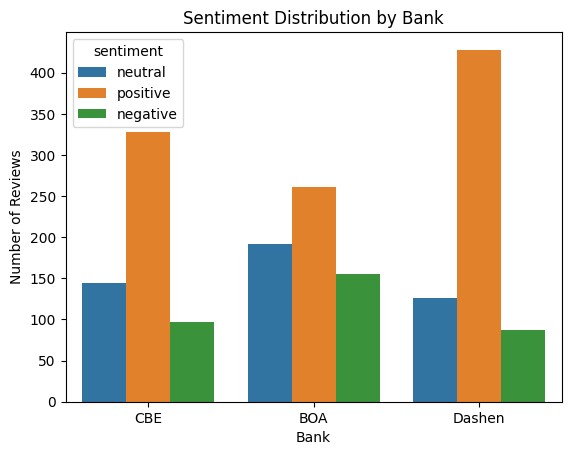

In [41]:
sns.countplot(data=all_reviews, x="bank", hue="sentiment")

plt.title("Sentiment Distribution by Bank")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")

plt.show()

<Axes: xlabel='rating'>

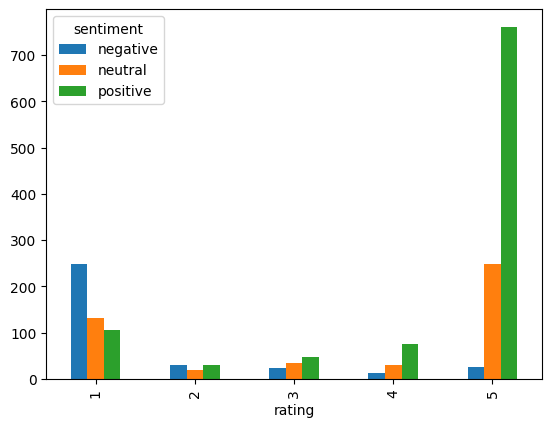

In [42]:
all_reviews.groupby("rating")["sentiment"].value_counts().unstack().plot(kind="bar")


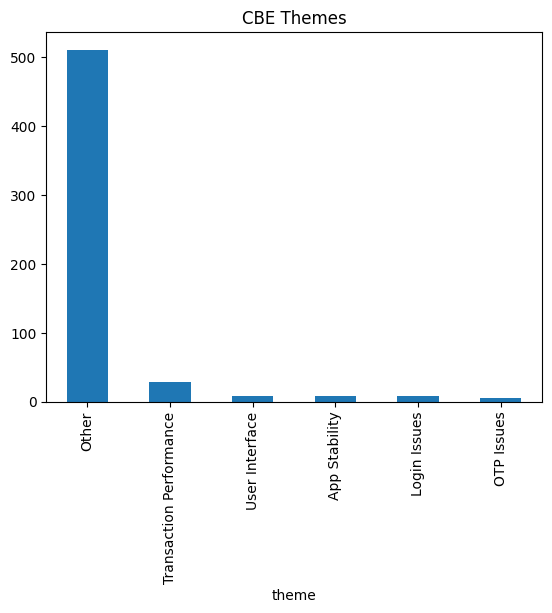

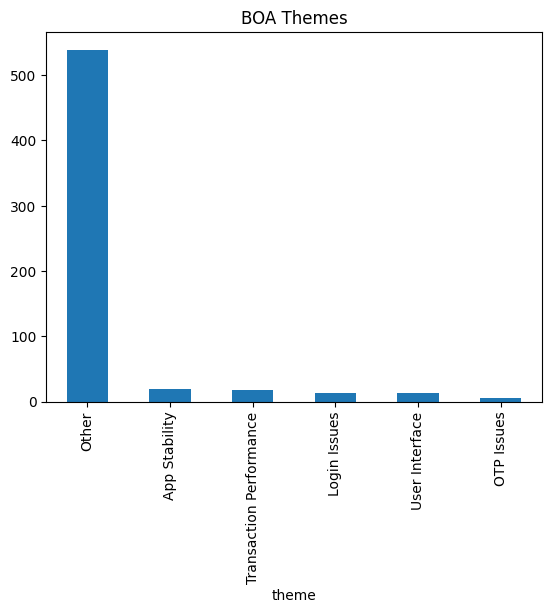

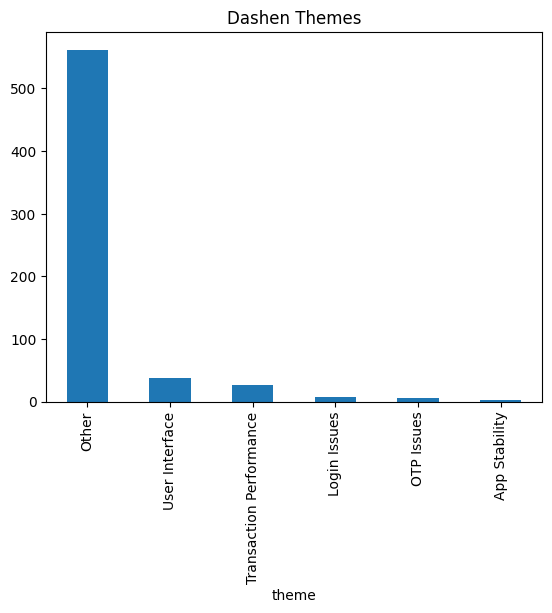

In [43]:
import matplotlib.pyplot as plt

cbe["theme"].value_counts().plot(kind="bar", title="CBE Themes")
plt.show()

boa["theme"].value_counts().plot(kind="bar", title="BOA Themes")
plt.show()

dashen["theme"].value_counts().plot(kind="bar", title="Dashen Themes")
plt.show()

<Axes: xlabel='bank'>

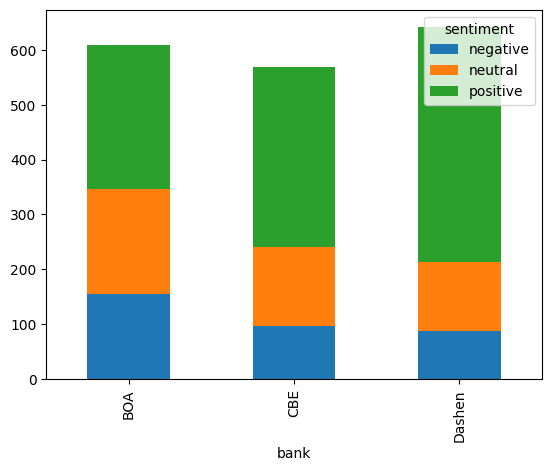

In [44]:
all_reviews.groupby("bank")["sentiment"].value_counts().unstack().plot(kind="bar", stacked=True)
